### INITIALIZATION & ENVIRONMENT SETUP

In [1]:
# Core numerical, data manipulation and visualization frameworks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('darkgrid')

In [2]:
# Load transformed and feature-engineered dataset
data = pd.read_csv('../data/bank_churn_data_cleaned.csv',
                   dtype={'CustomerId': str})

df = pd.DataFrame(data)

df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditScoreTier,BalanceSegment,SalaryGroup
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adults,Fair,Zero,Medium-High
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adults,Fair,Medium,Medium-High
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adults,Poor,High,Medium-High
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adults,Good,Zero,Medium-Low
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adults,Exceptional,Medium,Medium-Low


### UNIVARIATE ANALYSIS

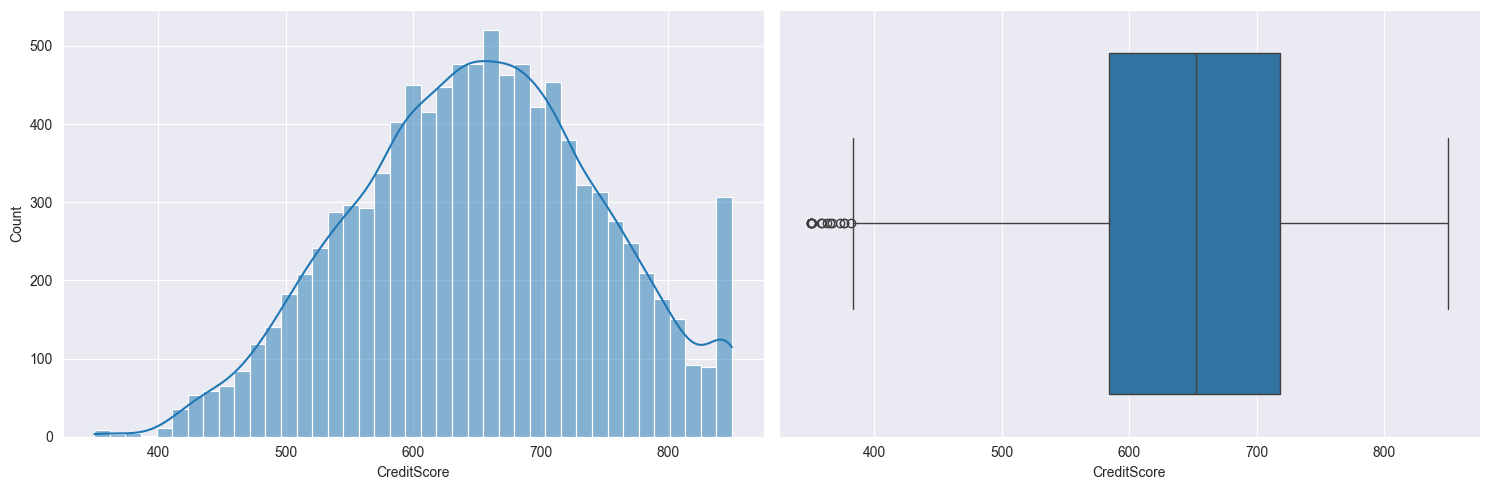

In [3]:
# Output CreditScore distribution dynamics and structural outlier analysis
fig, axes = plt.subplots(1,2, figsize= (15,5))
sns.histplot(data=df, ax=axes[0], x='CreditScore', kde=True)
sns.boxplot(data=df, x='CreditScore', ax= axes[1])
plt.tight_layout()
plt.show()

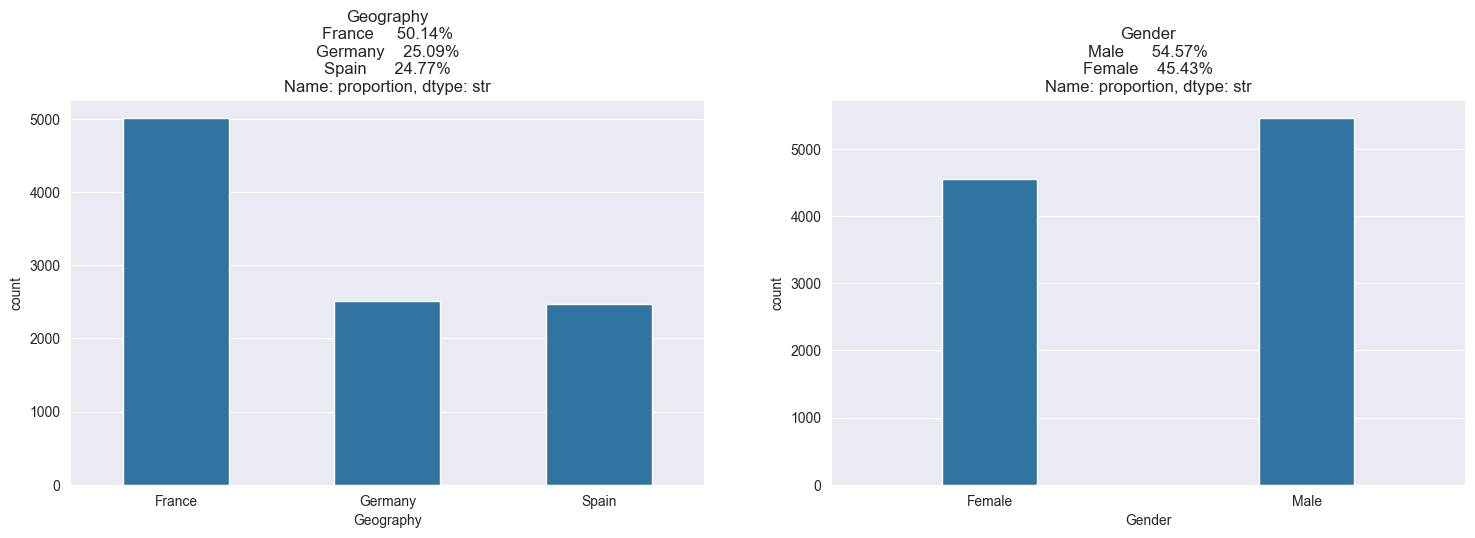

In [4]:
# Output geographic concentration patterns and gender demographic splits
fig, axes = plt.subplots(1,2, figsize= (18, 5))
sns.countplot(data=df, x='Geography', ax=axes[0], width=0.5, order=['France', 'Germany', 'Spain'])
axes[0].set_title(f'{(df['Geography'].value_counts(normalize=True)*100).round(2).astype(str) + '%'}')
sns.countplot(data=df, x='Gender', ax=axes[1], width=0.3)
axes[1].set_title(f'{(df['Gender'].value_counts(normalize=True)*100).round(2).astype(str) + '%'}')

plt.show()

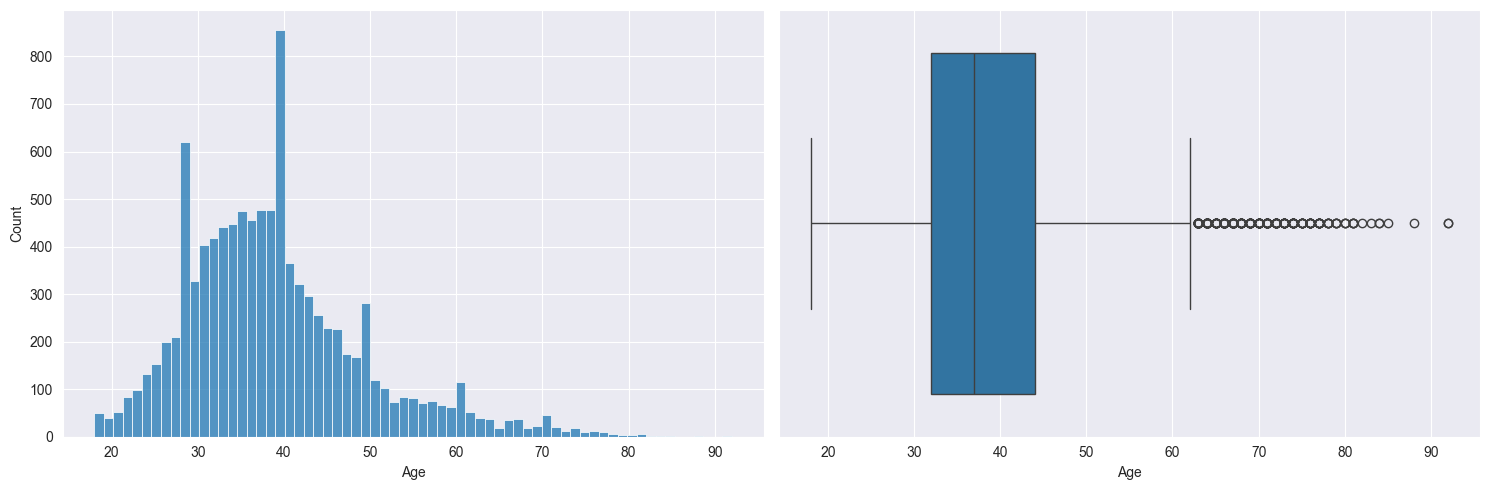

In [5]:
# Customers' age distribution 
fig, axes = plt.subplots(1,2, figsize= (15,5))
sns.histplot(data=df, ax=axes[0], x='Age')
sns.boxplot(data=df, x='Age', ax= axes[1])
plt.tight_layout()
plt.show()

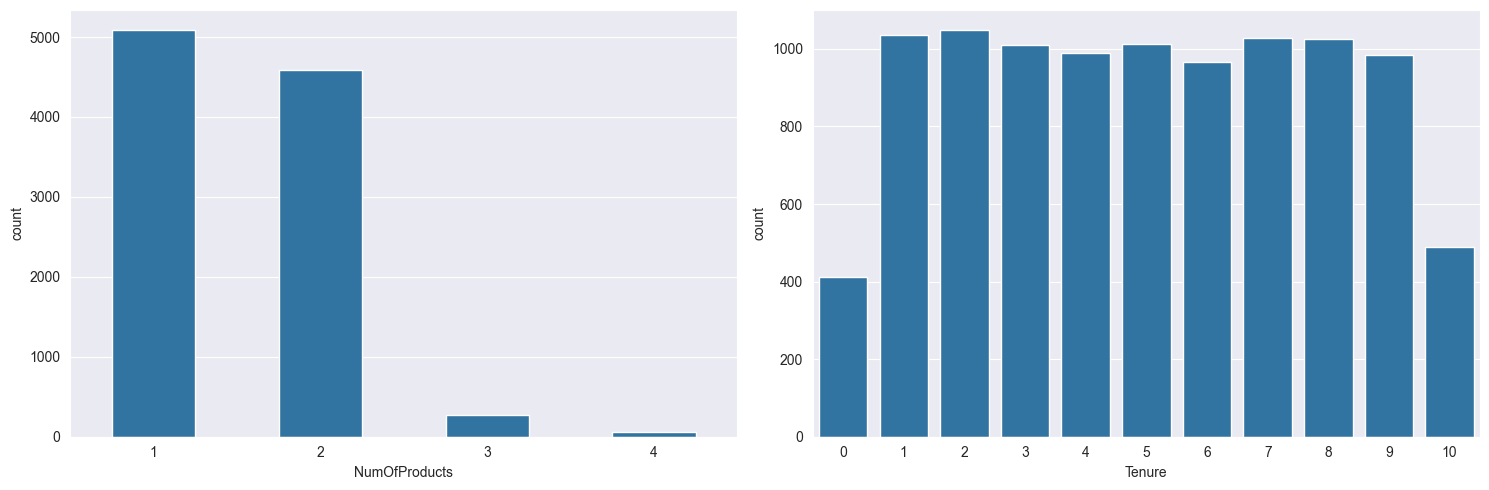

In [6]:
# Customers' product density and tenure footprints
fig, axes = plt.subplots(1,2, figsize= (15,5))
sns.countplot(data=df, ax=axes[0], x='NumOfProducts', width=0.5)
sns.countplot(data=df, x='Tenure', ax= axes[1])
plt.tight_layout()
plt.show()

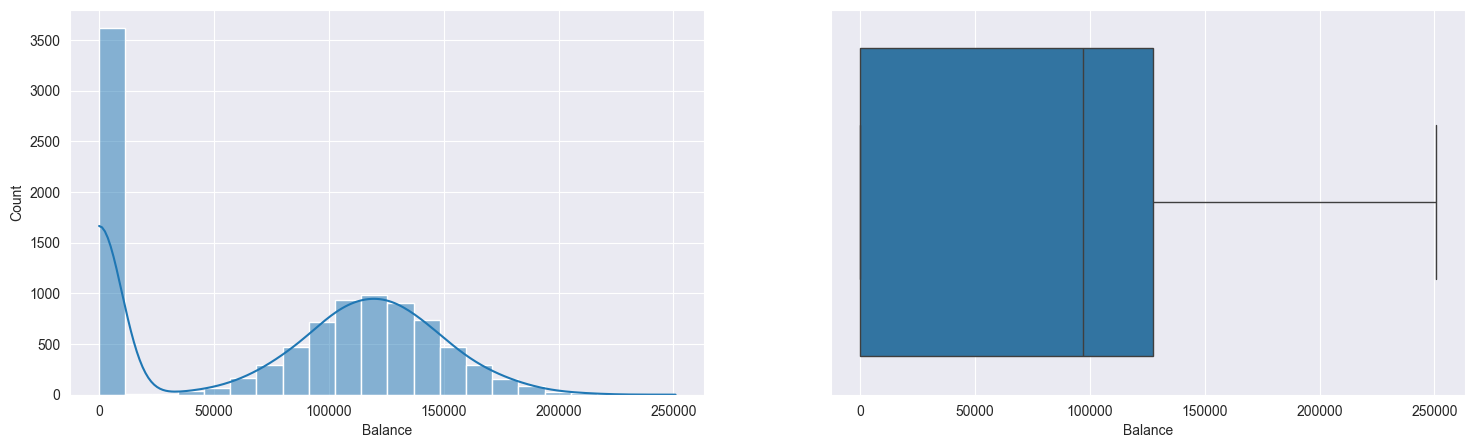

In [7]:
# Output balance concentration
fig, axes = plt.subplots(1,2, figsize=(18, 5))
sns.histplot(data=df, x='Balance', ax=axes[0], kde=True)
sns.boxplot(data=df, x='Balance', ax=axes[1])
plt.show()

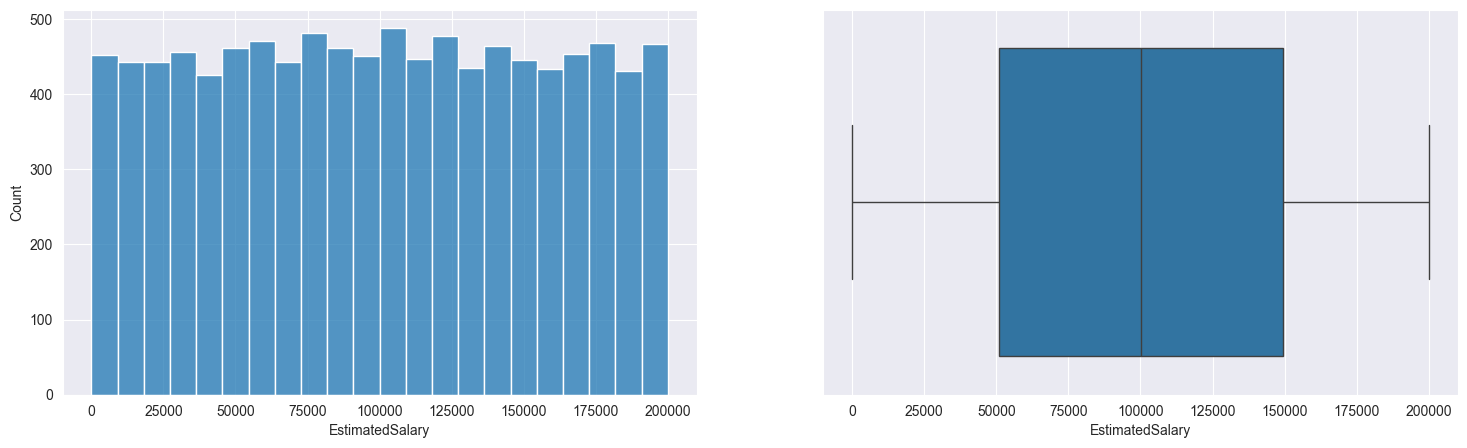

In [8]:
# Output estimated salary and economic earning distribution 
fig, axes = plt.subplots(1,2, figsize=(18, 5))
sns.histplot(data=df, x='EstimatedSalary', ax=axes[0])
sns.boxplot(data=df, x='EstimatedSalary', ax=axes[1])
plt.show()

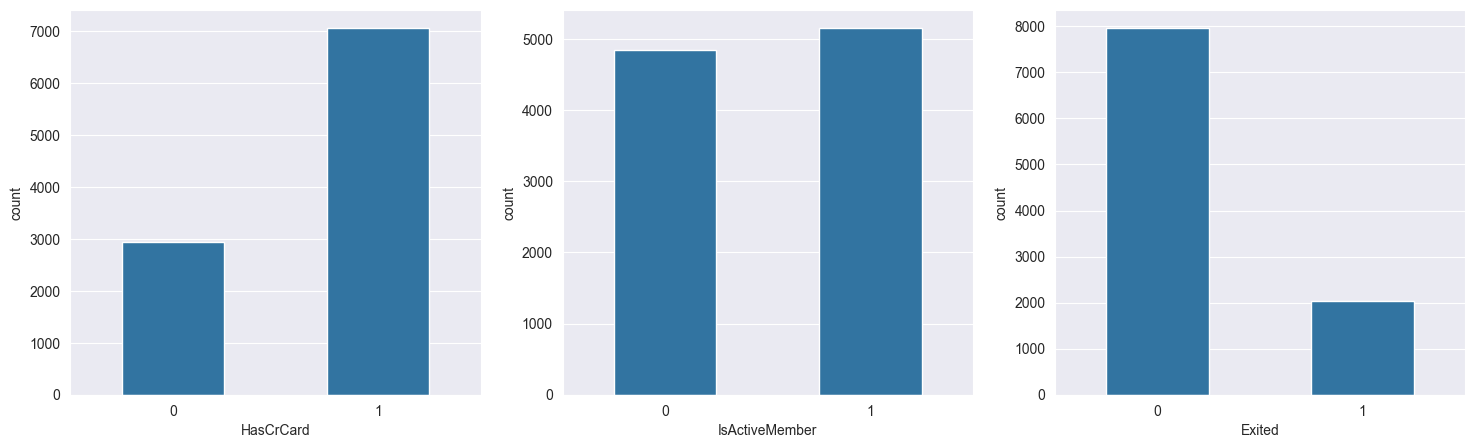

In [9]:
# Output financial tool coverage, platform interaction metrics, and baseline attrition metrics
fig, axes = plt.subplots(1,3, figsize=(18, 5))
sns.countplot(data=df, x='HasCrCard', ax=axes[0], width=0.5)
sns.countplot(data=df, x='IsActiveMember', ax=axes[1], width=0.5)
sns.countplot(data=df, x='Exited', ax=axes[2], width=0.5)
plt.show()

In [10]:
print((df['IsActiveMember'].value_counts(normalize=True)*100).round(2).astype(str) + '%')
print('='*175)

print((df['Exited'].value_counts(normalize=True)*100).round(2).astype(str) + '%')
print('='*175)

print((df['HasCrCard'].value_counts(normalize=True)*100).round(2).astype(str) + '%')


IsActiveMember
1    51.51%
0    48.49%
Name: proportion, dtype: str
Exited
0    79.63%
1    20.37%
Name: proportion, dtype: str
HasCrCard
1    70.55%
0    29.45%
Name: proportion, dtype: str


### VISUALIZATION

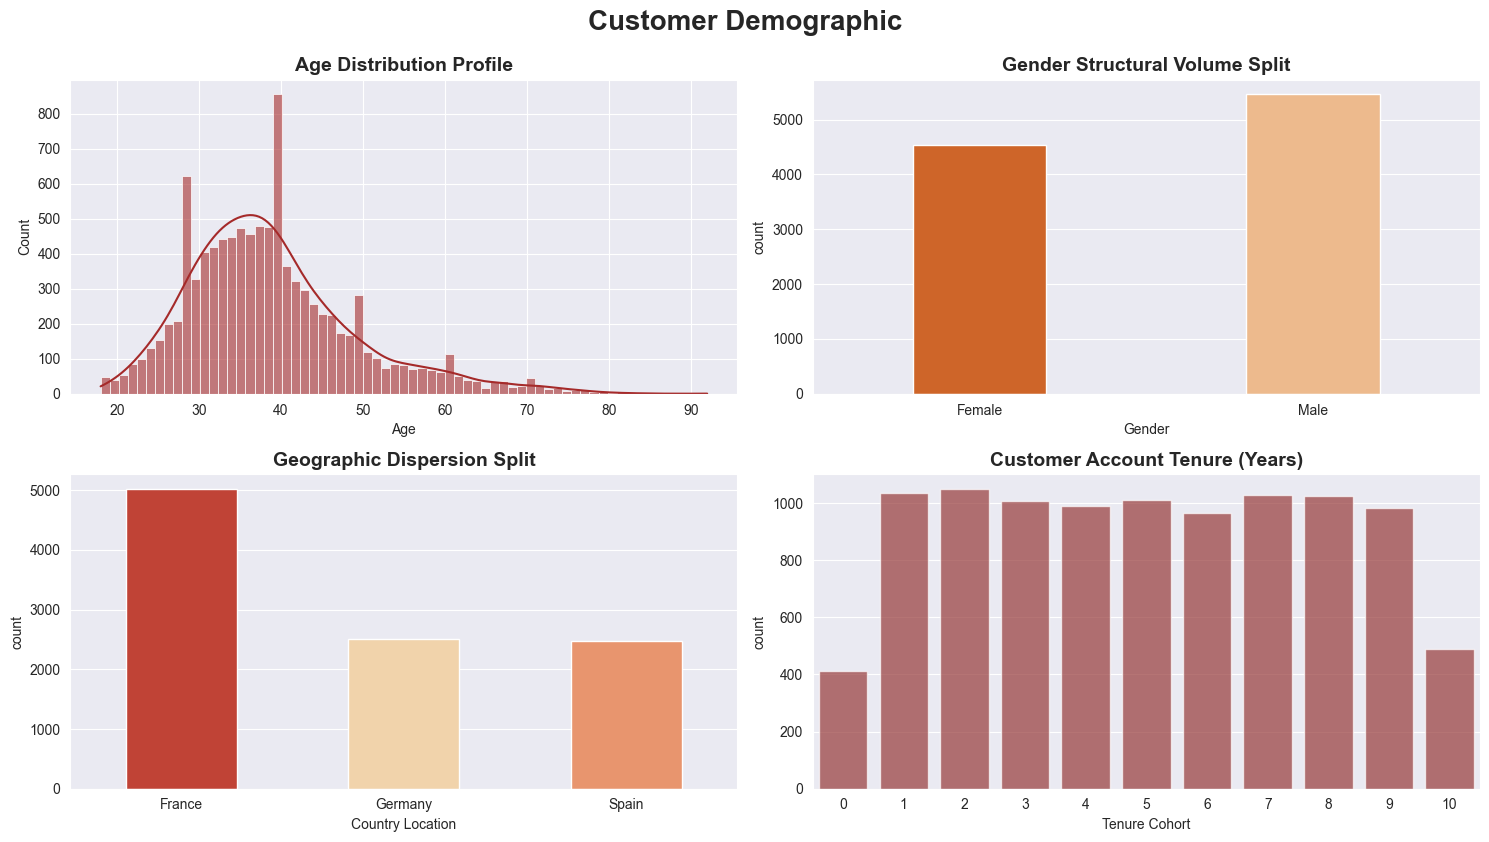

In [15]:
# DASHBOARD A: THE BANK'S DEMOGRAPHIC PROFILE

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Customer Demographic', fontsize=20, fontweight='bold', y=0.93)

# Axis (0,0): Age Distribution
sns.histplot(data=df, x='Age', kde=True, ax=axes[0, 0], color='brown', alpha=0.6)
axes[0, 0].set_title('Age Distribution Profile', fontsize=14, fontweight='semibold')
axes[0, 0].set_xlabel('Age')

# Axis (0,1): Gender Representation
sns.countplot(data=df, x='Gender', ax=axes[0, 1], palette='Oranges_r', width=0.4, hue='Gender')
axes[0, 1].set_title('Gender Structural Volume Split', fontsize=14, fontweight='semibold')
axes[0, 1].set_xlabel('Gender')

# Axis (1,0): Geographical Dispersion
sns.countplot(data=df, x='Geography', ax=axes[1, 0], palette='OrRd_r', width=0.5, order=['France', 'Germany', 'Spain'], hue='Geography')
axes[1, 0].set_title('Geographic Dispersion Split', fontsize=14, fontweight='semibold')
axes[1, 0].set_xlabel('Country Location')

# Axis (1,1): Brand Relationship Longevity
sns.countplot(data=df, x='Tenure', ax=axes[1, 1], color='brown', alpha=0.7)
axes[1, 1].set_title('Customer Account Tenure (Years)', fontsize=14, fontweight='semibold')
axes[1, 1].set_xlabel('Tenure Cohort')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('../reports/customer_demographic_profile.png', dpi=300, bbox_inches='tight')
plt.show()

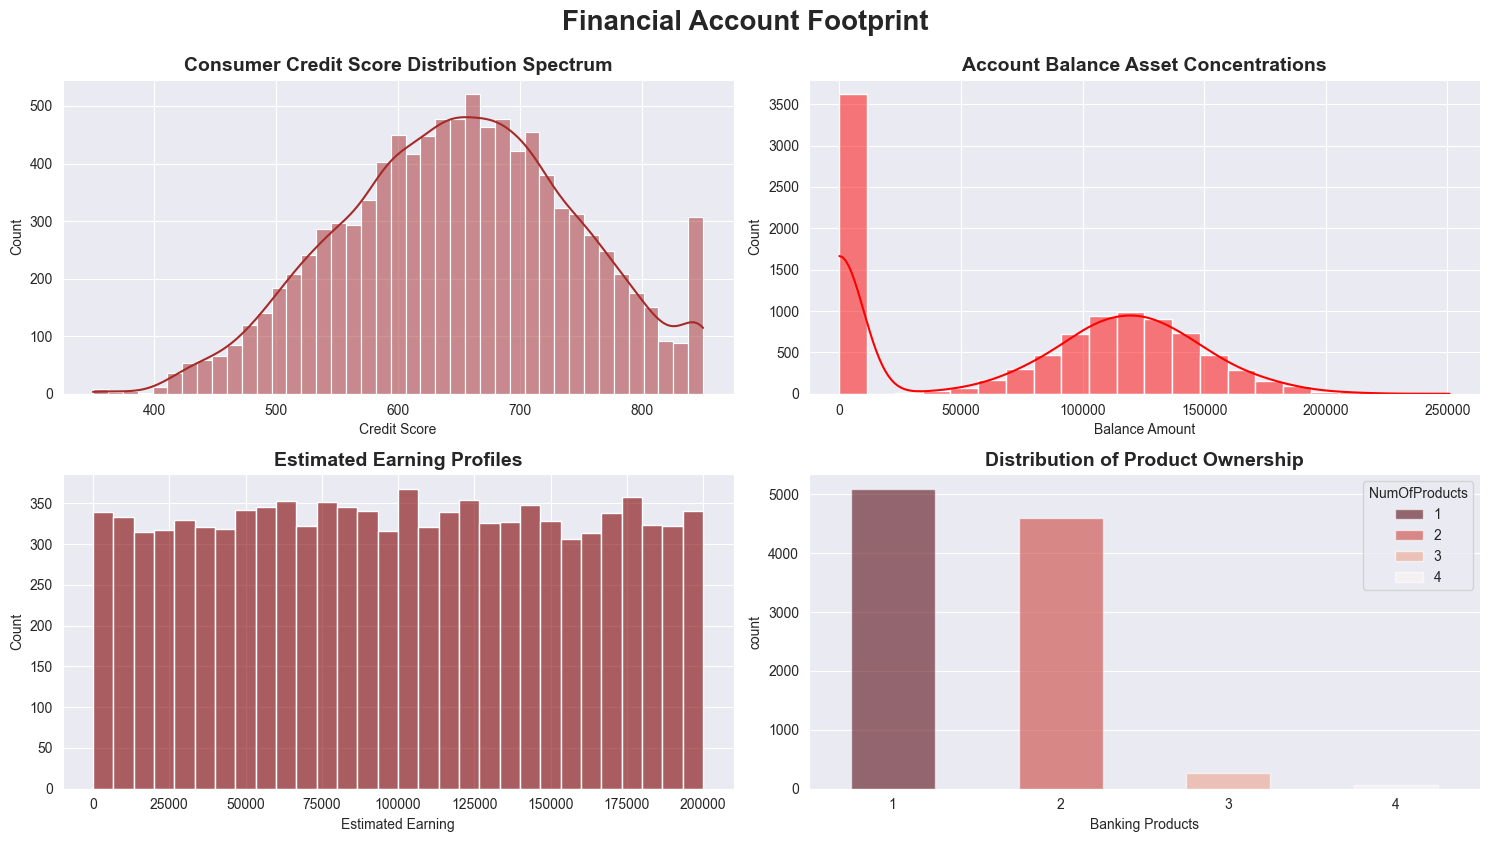

In [16]:
# DASHBOARD B: THE BANK'S FINANCIAL PROFILE

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Financial Account Footprint', fontsize=20, fontweight='bold', y=0.93)

# Axis (0,0): Consumer Credit Health
sns.histplot(data=df, x='CreditScore', kde=True, ax=axes[0, 0], color='brown')
axes[0, 0].set_title('Consumer Credit Score Distribution Spectrum', fontsize=14, fontweight='semibold')
axes[0, 0].set_xlabel('Credit Score')

# Axis (0,1): Balance Concentrations
sns.histplot(data=df, x='Balance', kde=True, ax=axes[0, 1], color='red', alpha=0.5)
axes[0, 1].set_title('Account Balance Asset Concentrations', fontsize=14, fontweight='semibold')
axes[0, 1].set_xlabel('Balance Amount')

# Axis (1,0): Salary Uniformity Assessment
sns.histplot(data=df, x='EstimatedSalary', ax=axes[1, 0], color='Maroon', bins=30, alpha=0.6)
axes[1, 0].set_title('Estimated Earning Profiles', fontsize=14, fontweight='semibold')
axes[1, 0].set_xlabel('Estimated Earning')

# Axis (1,1): Product Distribution Check
sns.countplot(data=df, x='NumOfProducts', ax=axes[1, 1], palette='Reds_r', width=0.5, hue='NumOfProducts', alpha=0.6)
axes[1, 1].set_title('Distribution of Product Ownership', fontsize=14, fontweight='semibold')
axes[1, 1].set_xlabel('Banking Products')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('../reports/financial_account_footprint.png', dpi=300, bbox_inches='tight')
plt.show()